<style>
    body {
        font-family: 'Arial', sans-serif;
        background-color: #f4f4f4;
        color: #333;
        line-height: 1.6;
    }

    .main-container {
        max-width: 940px;
        margin: 20px auto;
        background-color: #ffffff;
        border-radius: 8px;
        box-shadow: 0 2px 10px rgba(0, 0, 0, 0.1);
        padding: 20px;
    }

    h1.title {
        font-size: 3em;
        color: #0056b3; /* Darker blue for a more professional look */
        margin-bottom: 20px;
        font-weight: bold; /* Bold for emphasis */
        text-align: center; /* Center the title */
    }

    h2 {
        font-size: 2em;
        color: #007bff; /* Lighter blue for subheadings */
        margin-top: 40px;
        margin-bottom: 10px;
        font-weight: 600; /* Semi-bold for better visibility */
        border-bottom: 2px solid #e9ecef; /* Underline for emphasis */
        padding-bottom: 5px; /* Space below the heading */
    }

    h3 {
        font-size: 1.75em;
        color: #0056b3;
        margin-top: 20px;
        margin-bottom: 10px;
        font-weight: 500; /* Medium weight for sub-subheadings */
    }

    p {
        font-size: 1.2em;
        margin-bottom: 10px;
        line-height: 1.5; /* Increased line height for better readability */
    }

    pre {
        background-color: #f8f9fa;
        padding: 15px;
        border-radius: 5px;
        overflow-x: auto;
        border: 1px solid #ddd;
    }

    code {
        background-color: #e9ecef;
        padding: 2px 4px;
        border-radius: 4px;
    }

    .dataframe-container {
        overflow-x: auto; /* Enable horizontal scrolling */
        margin-bottom: 20px; /* Space below the DataFrame */
        border: 1px solid #ddd; /* Optional border for better visibility */
        border-radius: 5px; /* Rounded corners */
    }

    table {
        width: 100%; /* Ensure the table takes full width */
        border-collapse: collapse; /* Remove space between cells */
    }

    th, td {
        padding: 10px; /* Padding for table cells */
        text-align: left; /* Align text to the left */
        border-bottom: 1px solid #ddd; /* Light border for separation */
    }

    th {
        background-color: #ffffff; /* Change header background color to white */
        color: #333; /* Header text color */
        font-weight: bold; /* Bold header text */
    }

    tr:hover {
        background-color: #f1f1f1; /* Highlight row on hover */
    }

    .footer {
        text-align: center;
        margin-top: 20px;
        font-size: 0.9em;
        color: #6c757d;
    }

    /* Responsive adjustments */
    @media (max-width: 768px) {
        .main-container {
            padding: 15px;
        }

        h1.title {
            font-size: 2em;
        }

        h2, h3 {
            font-size: 1.5em;
        }
    }
</style>

## Introduction

In this notebook I fine-tune `bge-large-en-v1.5` model which is made for string embedding. 

This notebook can be run for fine-tuning in both of our approaches (both for similarity search and for mapping generated misconceptions onto true misconceptions).

Fine-tuning is done here by using a positive pairs of data:

- `source`: `ConstructName` + `SubjectName` + `QuestionText` + `Answer[A-D]Text` columns (i.e. `all_text` column) or misconceptions generated by LLM
- `target`: `MisconceptionName` I am are trying to predict

However, for a simpler explanation I will be only explaining a case where `source` is `all_text`. Especially, since fine-tuning the model where `source` are misconceptions generated by LLM is done the same way.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
    util,
    InputExample,
)
from sentence_transformers.losses import MultipleNegativesRankingLoss
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from datasets import Dataset

# Display the DataFrame in a scrollable container
from IPython.core.display import display, HTML

train_df = pd.read_csv("./data/train_df_train.csv")
test_df = pd.read_csv("./data/train_df_test.csv")
misconception_mapping = pd.read_csv("./data/misconception_mapping.csv")

training_first_retrieval = True

## Data Used for Fine-Tuning
Firstly, I need to extract from our loaded dataframe only two column, the `source` and the `target`.

In [4]:
train_df = train_df[train_df['MisconceptionId'].notna()]
test_df = test_df[test_df['MisconceptionId'].notna()]

# Join with misconception_mapping
train_df = train_df.merge(
    misconception_mapping,
    on='MisconceptionId',
    how='left'
)

test_df = test_df.merge(
    misconception_mapping,
    on='MisconceptionId',
    how='left'
)

After extracting from the `source` from the train dataset and `target` from the misconception mapping dataset. They look the following:

In [6]:
if training_first_retrieval:
    train_df["source"] = train_df["WholeAssignment"] + ". " + train_df["Answer_value"]
else:
    train_df.rename(columns={"MiscPredText": "source"}, inplace=True)
    
train_df.rename(columns={"MisconceptionName": "target"}, inplace=True)

train_df = train_df[["source", "target"]]

display(train_df)

,source,target
0,Use a bar model to express a ratio problem. Sh...,"When drawing bar diagram for ratio, shows the ..."
1,Identify a rectangle when presented non-conven...,Does not know the properties of a rectangle
2,Calculate the surface area of a cuboid where t...,Finds volume when asked for surface area
3,Describe a reflection in a vertical line by gi...,Thinks y = ? is a vertical line through ?
4,Describe a 90° or 270° rotation giving the ang...,Does not know about the + notation for directi...
...,...,...
3709,Interpret the value of digits in multiplicatio...,"When multiplying, treats digits in other colum..."
3710,Insert brackets to make a calculation correct....,Carries out operations from left to right rega...
3711,Calculate the square of a number. Function Mac...,Mixes up squaring and addition
3712,"Given a positive y value, find an x value in a...",Mixes up the value of two terms when substituting


# Fine-Tuning bge

Looking at the table above, I want to fine-tune the model so the values in the same row (pairs) will be then embedded in space close to each other, but values which are not in the same row to be far away from each other. To achieve this I use `MultipleNagativeRankingLoss` loss function from `SentenceTransformer`.

I also use test dataset for evaluation. As the evaluation metrics I choose `EmbeddingSimilarityEvaluator` from `SentenceTransformer`. This evaluates the model based on cosine similarity of the embeddings by calculating the Spearman and Pearson rank correlation in comparison to the ground-truth labels (more about hows this evaluator works [here](https://sbert.net/docs/package_reference/sentence_transformer/evaluation.html#embeddingsimilarityevaluator)).

I am also keeping most of the models hyperparameters default for `SentenceTransformer` fine-tuning. The only hyperparameter I change is `warmup_ratio` which is set to 0.1 (default is 0.0), since it marginally improved both loss and cosine similarity (loss improved approximately by 0.05 on average).

In [9]:
MODEL_NAME = "BAAI/bge-large-en-v1.5"
COMPETITION_NAME = "eedi-mining-misconceptions-in-mathematics"
MODEL_OUTPUT_PATH = "fine_tuned_bge_large"
RUN_NAME = "bge-large-en-v1.5-train-similarity-embedd"
EVAL_NAME = "embedding-similarity-test"

# Disable wandb
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
model = SentenceTransformer(MODEL_NAME)

def prepare_data(df):    
    # Ensure both columns are string type
    df['source'] = df['source'].astype(str)
    df['target'] = df['target'].astype(str)
    
    # Remove any rows with empty strings
    df = df[(df['source'] != '') & (df['target'] != '')]

    return df

train_dataset = Dataset.from_pandas(prepare_data(train_df))
test_dataset = Dataset.from_pandas(prepare_data(test_df))

loss = MultipleNegativesRankingLoss(model)

args = SentenceTransformerTrainingArguments(
    output_dir=MODEL_OUTPUT_PATH,
    num_train_epochs=15,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    fp16=True,
    bf16=False,
    batch_sampler="no_duplicates",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    logging_steps=200,
    run_name=RUN_NAME,
)

embeddings1 = model.encode(test_df["source"].tolist(), convert_to_tensor=True, normalize_embeddings=True)
embeddings2 = model.encode(test_df["target"].tolist(), convert_to_tensor=True, normalize_embeddings=True)

# Calculate cosine similarity between the two sets of embeddings
cosine_similarities = util.cos_sim(embeddings1, embeddings2).diagonal().cpu().numpy().tolist()

evaluator = EmbeddingSimilarityEvaluator(
    sentences1=test_df["MiscPredText"].tolist(),
    sentences2=test_df["MisconceptionName"].tolist(),
    scores=cosine_similarities,
    name="embedding-similarity-test",
)

trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset, 
    loss=loss,
    evaluator=evaluator,
)

trainer.train()

### Graph of loss and Spearman and Pearson correlation 

Plot of Loss and Correlation development over epochs when fine-tuning the bge-model for embedding in similarity search approach.|

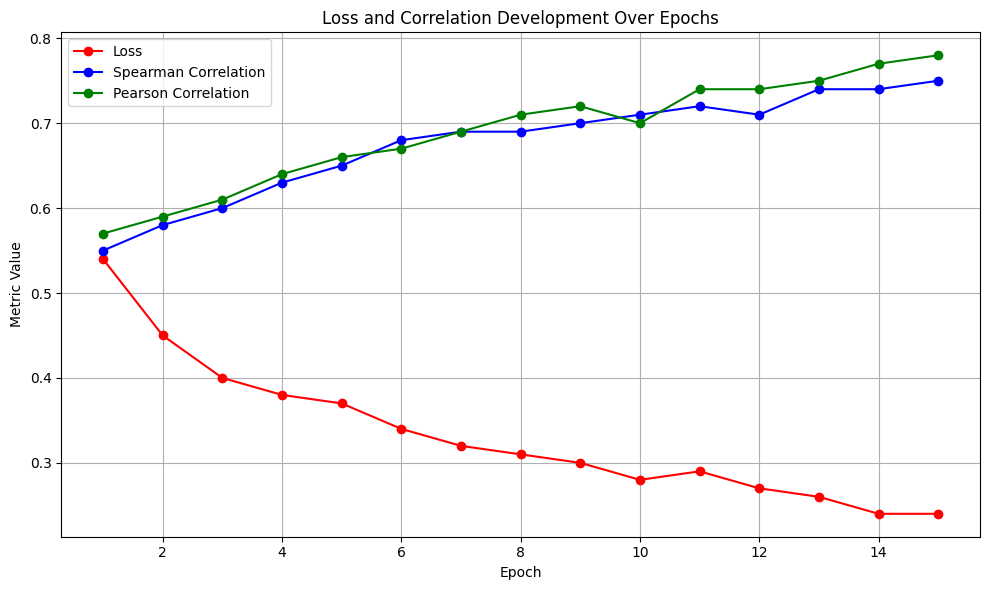

In [3]:
df = pd.read_csv("losses/bge_large_loss_final.csv")

epochs = range(1, len(df) + 1)
loss = df["Loss"]
spearman = df["Spearman"]
pearson = df["Pearson"]

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, label="Loss", color="red", marker="o")
plt.plot(epochs, spearman, label="Spearman Correlation", color="blue", marker="o")
plt.plot(epochs, pearson, label="Pearson Correlation", color="green", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("Loss and Correlation Development Over Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Summary and Potential Improvements

Looking at the loss and the correlation coefficients the embedding seems to be trained well. However, when using the embedding the our approaches the results are not overwhelming. Therefore, I assume there might be ways to improve on the embedding. 

One way to improve way of fine-tuning this embedding would be to not only use pairs of positive strings (source and target), but instead to use a triplet of strings (also known as anchor (`all_text` in our case), positive (correct `MisconceptionName`) and negative (incorrect `MisconceptionName`)).

Another way would be trying other models then just `bge-large-1.5` and/or tuning the models hyperparameters more.

Unfortunately, due to time restrictions I wasn't able to explore these paths.